# UART Verification Notebook

이 노트북은 UART 검증 데이터와 jitter tolerance sweep 결과를 `pandas`와
`matplotlib`로 정리합니다.

생성 그림:

- `figures/uart_baud_error_ppm.png`
- `figures/uart_tick_spacing.png`
- `figures/uart_coverage_heatmap.png`
- `figures/uart_timeline.png`
- `figures/uart_jitter_pass_fail_heatmap.png`
- `figures/uart_jitter_threshold_by_baud.png`
- `figures/uart_jitter_threshold_ns.png`

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd()
DOCS = ROOT
FIGS = DOCS / "figures"
FIGS.mkdir(parents=True, exist_ok=True)

baud_df = pd.read_csv(DOCS / "uart_baud_error_table.csv")
sweep_df = pd.read_csv(DOCS / "uart_jitter_sweep_results.csv")
threshold_df = pd.read_csv(DOCS / "uart_jitter_threshold_summary.csv")

coverage_df = pd.DataFrame({
    "Reset / ID":      [1, 1, 1, 1, 1, 0, 0, 0, 0, 0],
    "TX Path":         [0, 0, 0, 0, 0, 1, 1, 0, 0, 0],
    "RX Normal":       [0, 1, 1, 0, 1, 0, 0, 1, 0, 0],
    "RX Jitter":       [0, 0, 0, 0, 0, 0, 0, 1, 1, 0],
    "Frame Error":     [0, 1, 1, 0, 1, 0, 0, 0, 1, 1],
    "RX Overflow":     [0, 1, 1, 0, 1, 0, 0, 1, 0, 1],
    "Assertion":       [0, 0, 0, 1, 1, 0, 0, 0, 0, 0],
}, index=[
    "APB ID path",
    "APB STATUS path",
    "APB read known",
    "pready const-high",
    "TX idle on reset",
    "TX FIFO enqueue",
    "TX serial correctness",
    "RX data path",
    "Jitter tolerance",
    "Error / boundary handling",
])

timeline_df = pd.DataFrame([
    {"time_us": 0.095,      "event": "Directed test start"},
    {"time_us": 0.115,      "event": "UART_ID matched"},
    {"time_us": 0.145,      "event": "UART_STATUS reset matched"},
    {"time_us": 82.660,     "event": "TX byte 0x55 matched"},
    {"time_us": 169.400,    "event": "TX byte 0xA3 matched"},
    {"time_us": 256.210,    "event": "TX byte 0x0D matched"},
    {"time_us": 364.765,    "event": "RX normal byte matched"},
    {"time_us": 364.795,    "event": "RX empty observed"},
    {"time_us": 469.015,    "event": "RX jittered byte matched"},
    {"time_us": 573.205,    "event": "Frame error set"},
    {"time_us": 573.295,    "event": "Frame error cleared"},
    {"time_us": 4010.825,   "event": "RX overflow set"},
    {"time_us": 4012.745,   "event": "RX overflow drain[31] matched"},
    {"time_us": 4012.835,   "event": "RX overflow cleared"},
    {"time_us": 4012.835,   "event": "Directed test finished"},
    {"time_us": 4013.835,   "event": "Simulation PASS"},
])

jitter_matrix = sweep_df.pivot(index="baud_rate", columns="jitter_percent", values="passed").sort_index()

baud_df.head(), threshold_df

(    baud  target_tick_hz  actual_tick_hz  error_percent  error_ppm  \
 0   9600        153600.0   153601.169586       0.000761      7.614   
 1  14400        230400.0   230401.754379       0.000761      7.614   
 2  19200        307200.0   307202.339172       0.000761      7.614   
 3  38400        614400.0   614398.717880      -0.000209     -2.087   
 4  57600        921600.0   921601.057053       0.000115      1.147   
 
    tick_min_clk  tick_max_clk  bit_min_clk  bit_max_clk  
 0           651           652        10416        10417  
 1           434           435         6944         6945  
 2           325           326         5208         5209  
 3           162           163         2604         2605  
 4           108           109         1736         1737  ,
    baud_sel  baud_rate  max_pass_jitter_permille  max_pass_jitter_percent  \
 0         0       9600                       430                     43.0   
 1         1      14400                       430            

## Summary

이 노트북은 아래 질문에 답하도록 구성했습니다.

1. 지원 baud별 평균 baud 오차는 얼마나 작은가?
2. tick quantization은 baud에 따라 어떻게 달라지는가?
3. directed scenario는 어떤 기능을 커버하는가?
4. jitter sweep에서 각 baud는 몇 %까지 PASS하는가?
5. 같은 PASS 한계라도 ns 기준으로 보면 얼마나 다른가?

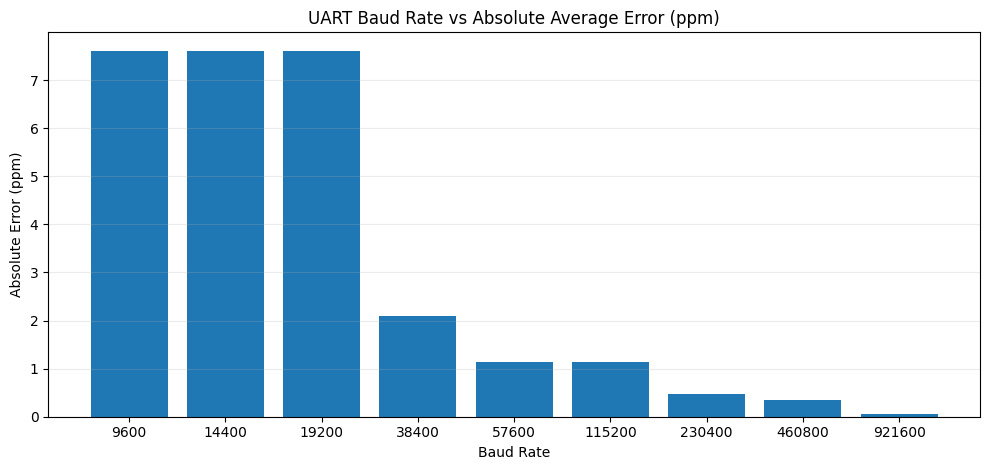

D:\risc_team\RISC-V_Multi_Cycle\docs\figures\uart_baud_error_ppm.png


In [2]:
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.bar(baud_df["baud"].astype(str), baud_df["error_ppm"].abs(), color="#1f77b4")
ax.set_title("UART Baud Rate vs Absolute Average Error (ppm)")
ax.set_xlabel("Baud Rate")
ax.set_ylabel("Absolute Error (ppm)")
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
out = FIGS / "uart_baud_error_ppm.png"
fig.savefig(out, dpi=180, bbox_inches="tight")
plt.show()
print(out)

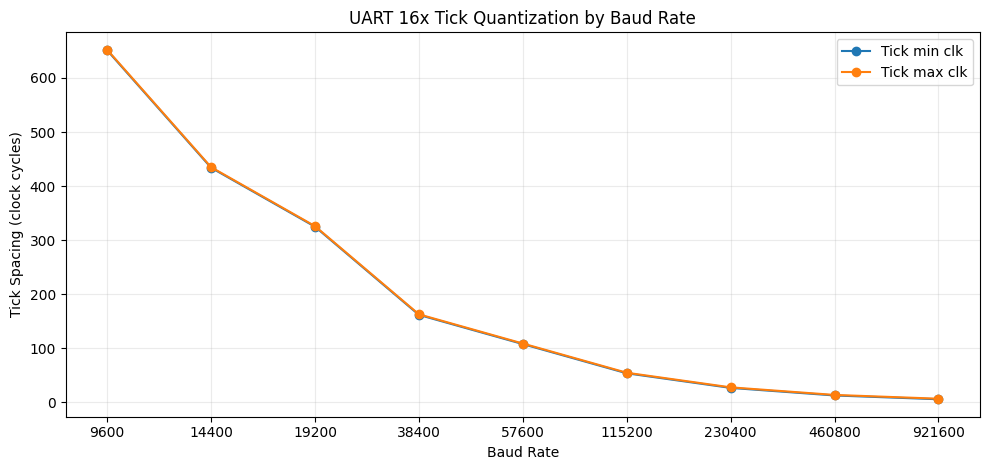

D:\risc_team\RISC-V_Multi_Cycle\docs\figures\uart_tick_spacing.png


In [3]:
fig, ax = plt.subplots(figsize=(10, 4.8))
x = np.arange(len(baud_df))
ax.plot(x, baud_df["tick_min_clk"], marker="o", label="Tick min clk")
ax.plot(x, baud_df["tick_max_clk"], marker="o", label="Tick max clk")
ax.set_xticks(x, baud_df["baud"].astype(str))
ax.set_title("UART 16x Tick Quantization by Baud Rate")
ax.set_xlabel("Baud Rate")
ax.set_ylabel("Tick Spacing (clock cycles)")
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
out = FIGS / "uart_tick_spacing.png"
fig.savefig(out, dpi=180, bbox_inches="tight")
plt.show()
print(out)

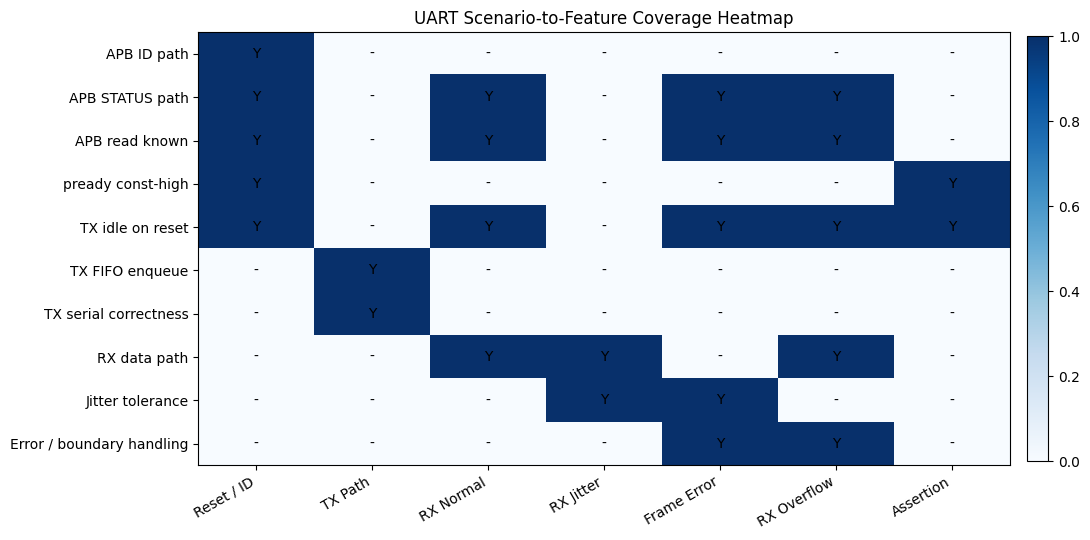

D:\risc_team\RISC-V_Multi_Cycle\docs\figures\uart_coverage_heatmap.png


In [4]:
fig, ax = plt.subplots(figsize=(11, 5.5))
img = ax.imshow(coverage_df.values, cmap="Blues", aspect="auto", vmin=0, vmax=1)
ax.set_xticks(np.arange(len(coverage_df.columns)), coverage_df.columns, rotation=30, ha="right")
ax.set_yticks(np.arange(len(coverage_df.index)), coverage_df.index)
ax.set_title("UART Scenario-to-Feature Coverage Heatmap")
for row in range(coverage_df.shape[0]):
    for col in range(coverage_df.shape[1]):
        ax.text(col, row, "Y" if coverage_df.iloc[row, col] else "-", ha="center", va="center", color="black")
fig.colorbar(img, ax=ax, fraction=0.025, pad=0.02)
fig.tight_layout()
out = FIGS / "uart_coverage_heatmap.png"
fig.savefig(out, dpi=180, bbox_inches="tight")
plt.show()
print(out)

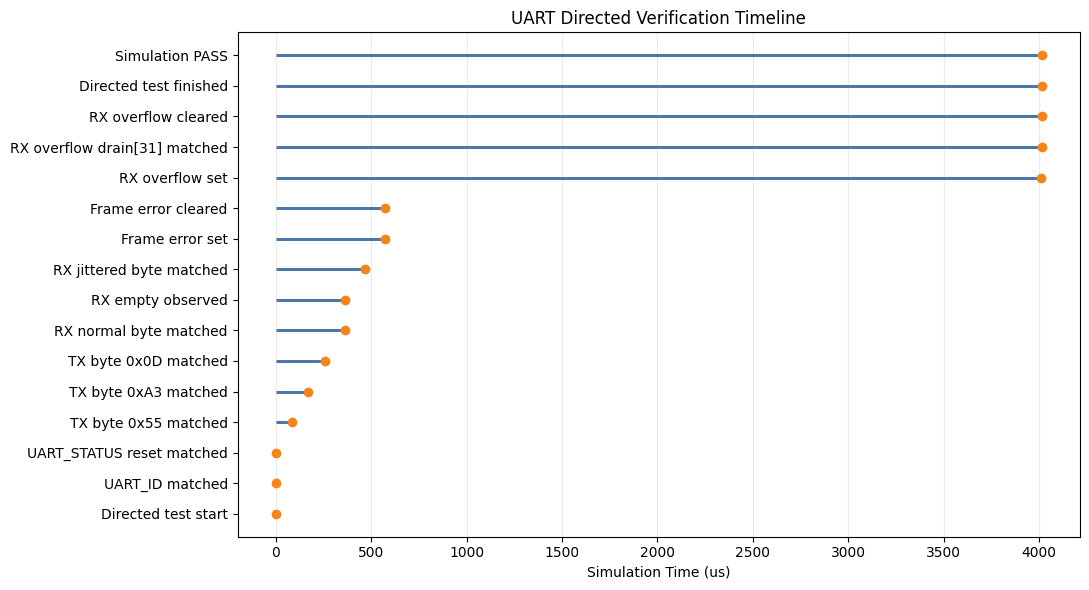

D:\risc_team\RISC-V_Multi_Cycle\docs\figures\uart_timeline.png


In [5]:
fig, ax = plt.subplots(figsize=(11, 6))
y = np.arange(len(timeline_df))
ax.hlines(y, 0, timeline_df["time_us"], color="#4c78a8", linewidth=2.2)
ax.plot(timeline_df["time_us"], y, "o", color="#f58518")
ax.set_yticks(y, timeline_df["event"])
ax.set_xlabel("Simulation Time (us)")
ax.set_title("UART Directed Verification Timeline")
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
out = FIGS / "uart_timeline.png"
fig.savefig(out, dpi=180, bbox_inches="tight")
plt.show()
print(out)

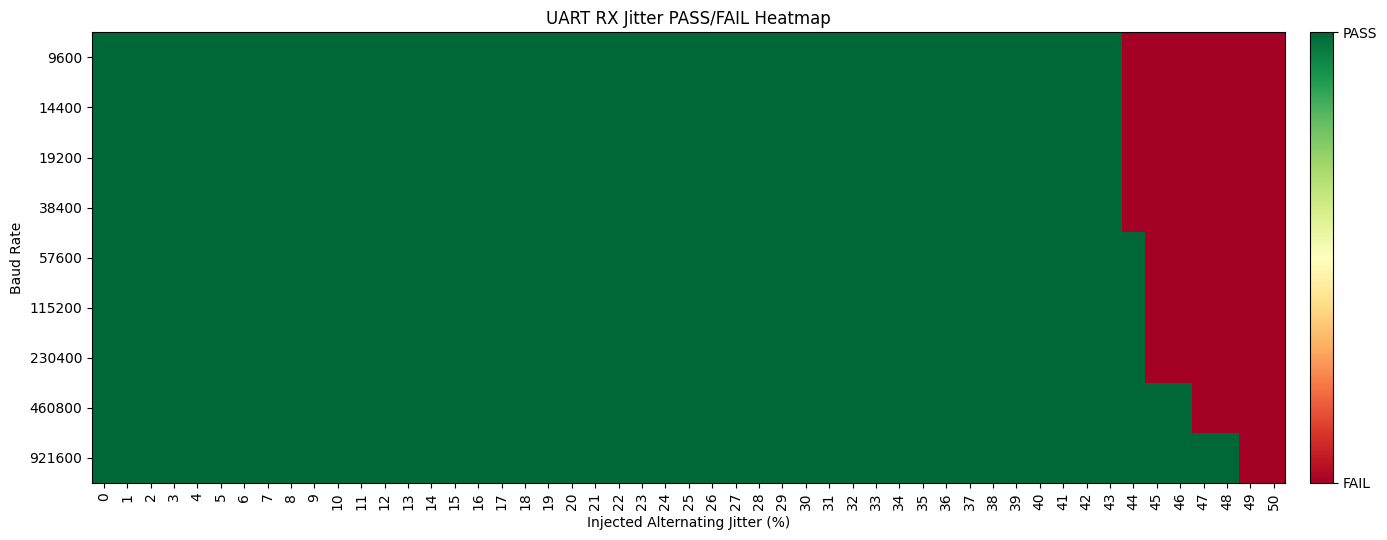

D:\risc_team\RISC-V_Multi_Cycle\docs\figures\uart_jitter_pass_fail_heatmap.png


In [6]:
fig, ax = plt.subplots(figsize=(14, 5.5))
img = ax.imshow(jitter_matrix.values, cmap="RdYlGn", aspect="auto", vmin=0, vmax=1)
ax.set_xticks(np.arange(len(jitter_matrix.columns)), [f"{v:.0f}" for v in jitter_matrix.columns], rotation=90)
ax.set_yticks(np.arange(len(jitter_matrix.index)), jitter_matrix.index.astype(str))
ax.set_title("UART RX Jitter PASS/FAIL Heatmap")
ax.set_xlabel("Injected Alternating Jitter (%)")
ax.set_ylabel("Baud Rate")
cbar = fig.colorbar(img, ax=ax, fraction=0.025, pad=0.02)
cbar.set_ticks([0, 1], labels=["FAIL", "PASS"])
fig.tight_layout()
out = FIGS / "uart_jitter_pass_fail_heatmap.png"
fig.savefig(out, dpi=180, bbox_inches="tight")
plt.show()
print(out)

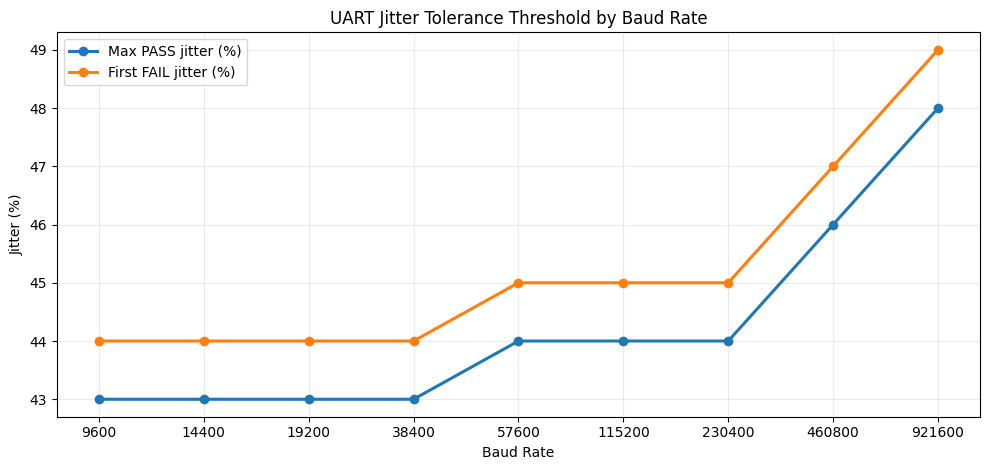

D:\risc_team\RISC-V_Multi_Cycle\docs\figures\uart_jitter_threshold_by_baud.png


In [7]:
fig, ax = plt.subplots(figsize=(10, 4.8))
x = np.arange(len(threshold_df))
ax.plot(x, threshold_df["max_pass_jitter_percent"], marker="o", linewidth=2.2, label="Max PASS jitter (%)")
ax.plot(x, threshold_df["first_fail_jitter_percent"], marker="o", linewidth=2.2, label="First FAIL jitter (%)")
ax.set_xticks(x, threshold_df["baud_rate"].astype(str))
ax.set_title("UART Jitter Tolerance Threshold by Baud Rate")
ax.set_xlabel("Baud Rate")
ax.set_ylabel("Jitter (%)")
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
out = FIGS / "uart_jitter_threshold_by_baud.png"
fig.savefig(out, dpi=180, bbox_inches="tight")
plt.show()
print(out)

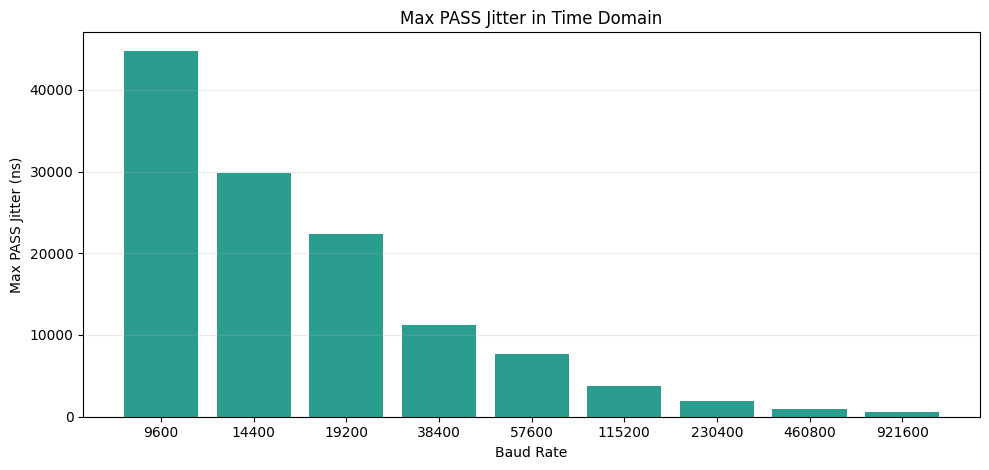

D:\risc_team\RISC-V_Multi_Cycle\docs\figures\uart_jitter_threshold_ns.png


In [8]:
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.bar(threshold_df["baud_rate"].astype(str), threshold_df["max_pass_jitter_ns"], color="#2a9d8f")
ax.set_title("Max PASS Jitter in Time Domain")
ax.set_xlabel("Baud Rate")
ax.set_ylabel("Max PASS Jitter (ns)")
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
out = FIGS / "uart_jitter_threshold_ns.png"
fig.savefig(out, dpi=180, bbox_inches="tight")
plt.show()
print(out)